# LAB 02 — N-gram Language Models: Experiments

Notebook này dùng trực tiếp `ngram_lm.py` để thực hiện các thí nghiệm của LAB 02:

- Experiment 1 — Corpus statistics
- Zero probability
- Experiment 2 — MLE vs Laplace smoothing
- Experiment 3 — Perplexity trên train / validation / test
- Application — Next-word prediction
- Application — Sentence ranking
- Context-length summary: unigram / bigram / trigram
- Xuất `results.csv`

> **Lưu ý:** Bản notebook này đã bổ sung phần phân tích dựa trực tiếp trên output đã chạy. Các phần *prediction trước experiment*, *giải thích kết quả*, *error analysis* và *reflection* cần tự viết theo yêu cầu của LAB.

> Nếu chưa cấu hình corpus thật, notebook dùng một **DEMO_CORPUS** nhỏ để kiểm tra pipeline. Không dùng kết quả demo làm kết quả nộp bài.


In [ ]:
# 1. Imports
from pathlib import Path
import gzip
import json
import math
import random
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

from ngram_lm import (
    NGramLanguageModel,
    build_vocabulary,
    count_ngrams,
    tokenize,
)

pd.set_option("display.max_colwidth", 120)


## 2. Đọc corpus




In [ ]:
# 2. Configuration
DATA_PATH = "/content/c4-train.00000-of-01024-30K.json.gz"

MAX_DOCUMENTS = 30000
LOWERCASE = False

SPLIT_SENTENCES = True

TRAIN_RATIO = 0.80
VALID_RATIO = 0.10
TEST_RATIO = 0.10

SEED = 42
TOP_K = 5


In [ ]:
# 3. Load C4 data - cùng cách đọc với experiments cũ
path = DATA_PATH

data = []
with gzip.open(path, "rt", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            data.append(json.loads(line))

        if MAX_DOCUMENTS is not None and len(data) >= MAX_DOCUMENTS:
            break

df = pd.DataFrame(data)

if "text" not in df.columns:
    raise KeyError("Dataset không có cột text.")

docs = df["text"].fillna("").tolist()
documents = docs


def normalize_text(text):
    text = str(text).strip()
    if LOWERCASE:
        text = text.lower()
    return text


def split_sentences(document):
    document = normalize_text(document)
    if not document:
        return []

    if not SPLIT_SENTENCES:
        return [document]

    # Tách đơn giản theo dấu kết thúc câu hoặc xuống dòng.
    parts = re.split(r"(?<=[.!?])\s+|\n+", document)
    return [part.strip() for part in parts if part.strip()]


def documents_to_sentences(document_list):
    result = []
    for document in document_list:
        result.extend(split_sentences(document))
    return result


sentences = documents_to_sentences(documents)

print("Number of documents:", len(docs))
print("Number of sentences:", len(sentences))
print("\nFirst document preview:")
print(docs[0][:300] if docs else "EMPTY")


Number of documents: 30000
Number of sentences: 636925

First document preview:
Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You will have the opportunity, put this on your calendar now. Thursday, September 22nd join World Class BBQ Champion, Tony Balay from Lonestar Smoke Rangers. He will be teaching a beginner level class fo


## 4. Sanity check với corpus mẫu trong đề

Ô này kiểm tra nhanh implementation trước khi chạy corpus lớn.


In [ ]:
# 4. Sanity check
toy_corpus = [
    "the cat eats fish",
    "the cat likes fish",
    "the dog eats meat",
]

toy_bigram = NGramLanguageModel(n=2).fit(toy_corpus)

assert abs(toy_bigram.probability("the", "cat") - 2/3) < 1e-12
assert abs(toy_bigram.probability("the", "dog") - 1/3) < 1e-12
assert abs(toy_bigram.probability("cat", "eats") - 1/2) < 1e-12
assert abs(toy_bigram.probability("cat", "likes") - 1/2) < 1e-12
assert abs(toy_bigram.sentence_probability("the cat eats fish") - 1/24) < 1e-12

print("Sanity check: PASSED")


Sanity check: PASSED


# Experiment 1 — Corpus statistics

Thống kê:

- số documents;
- số sentences;
- số tokens;
- vocabulary size;
- số unique unigram / bigram / trigram;
- số n-gram chỉ xuất hiện một lần.


In [ ]:
# 5. Basic corpus statistics
all_tokens = []
for sentence in sentences:
    all_tokens.extend(tokenize(sentence))

vocabulary = build_vocabulary(sentences)

basic_stats = pd.DataFrame({
    "Metric": [
        "# documents",
        "# sentences",
        "# tokens",
        "vocabulary size",
    ],
    "Value": [
        len(documents),
        len(sentences),
        len(all_tokens),
        len(vocabulary),
    ],
})

basic_stats


,Metric,Value
0,# documents,30000
1,# sentences,636925
2,# tokens,10832672
3,vocabulary size,542753


In [ ]:
# 6. N-gram statistics
ngram_counts = {
    1: count_ngrams(sentences, 1),
    2: count_ngrams(sentences, 2),
    3: count_ngrams(sentences, 3),
}

ngram_stats = []

for n in (1, 2, 3):
    counts = ngram_counts[n]
    singleton_count = sum(1 for count in counts.values() if count == 1)

    ngram_stats.append({
        "Model": {1: "Unigram", 2: "Bigram", 3: "Trigram"}[n],
        "# unique n-grams": len(counts),
        "# n-grams appearing once": singleton_count,
    })

ngram_stats_df = pd.DataFrame(ngram_stats)
ngram_stats_df


,Model,# unique n-grams,# n-grams appearing once
0,Unigram,542753,334799
1,Bigram,3607892,2802705
2,Trigram,6888794,6123696


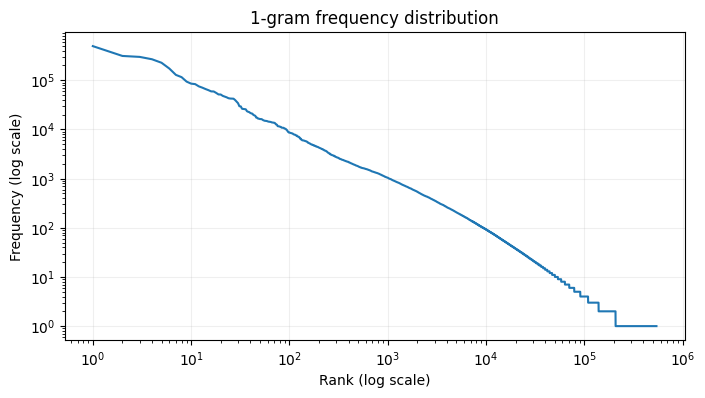

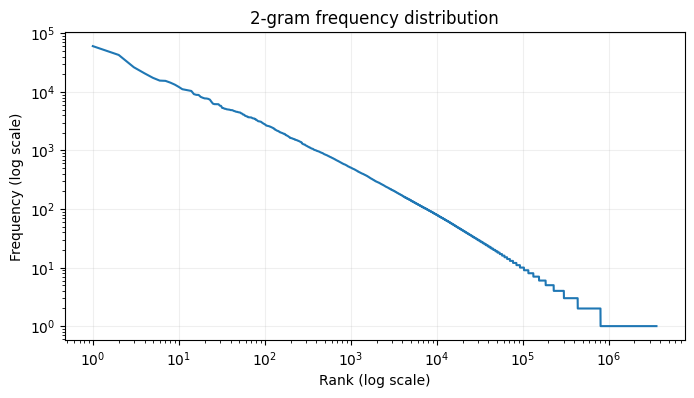

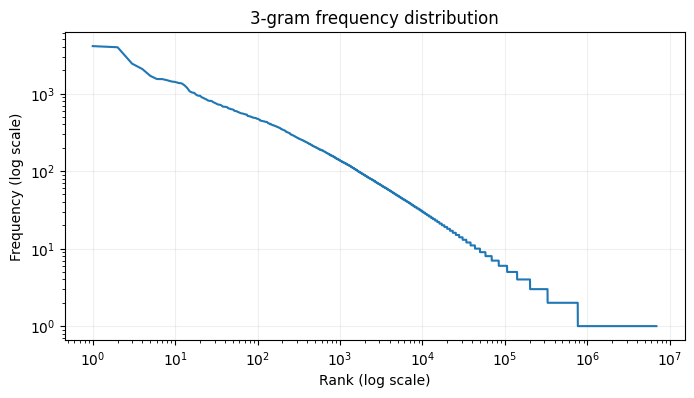

In [ ]:
# 7. Frequency distribution
# Rank-frequency plot: n-grams are sorted from most frequent to least frequent.
for n in (1, 2, 3):
    frequencies = sorted(ngram_counts[n].values(), reverse=True)

    plt.figure(figsize=(8, 4))
    if frequencies:
        ranks = range(1, len(frequencies) + 1)
        plt.plot(ranks, frequencies)
        plt.xscale("log")
        plt.yscale("log")

    plt.title(f"{n}-gram frequency distribution")
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.grid(alpha=0.2)
    plt.show()


### Phân tích Experiment 1 — Corpus statistics

Corpus thực tế gồm **30,000 documents**, **636,925 sentences** và **10,832,672 tokens**, với vocabulary size **542,753**. Trung bình mỗi document có khoảng **21.23 câu**, mỗi document khoảng **361.09 token**, và mỗi câu khoảng **17.01 token**.

Số unique n-gram tăng rất mạnh khi tăng \(n\):

- Unigram: **542,753**
- Bigram: **3,607,892**
- Trigram: **6,888,794**

Điều đáng chú ý hơn là số n-gram chỉ xuất hiện **một lần**:

- Unigram: **334,799 / 542,753 ≈ 61.69%**
- Bigram: **2,802,705 / 3,607,892 ≈ 77.68%**
- Trigram: **6,123,696 / 6,888,794 ≈ 88.89%**

Như vậy khi tăng từ unigram lên trigram, số context cụ thể tăng rất nhanh và phần lớn trigram chỉ xuất hiện một lần. Đây là dấu hiệu rất rõ của **data sparsity**.

Các rank-frequency plot cũng cần được đọc theo hướng này: một nhóm nhỏ n-gram có tần suất rất cao, trong khi phần đuôi chứa rất nhiều n-gram hiếm. Hiện tượng này càng mạnh với bigram và trigram.


## 5. Train / validation / test split

Split trên `docs` (document) trước, sau đó mới tách sentence trong từng split. Như vậy các sentence của cùng một C4 document không bị rơi vào nhiều tập khác nhau.


In [ ]:
# 8. Deterministic document split
def split_documents(documents, train_ratio=0.8, valid_ratio=0.1, seed=42):
    documents = list(documents)

    if len(documents) < 3:
        raise ValueError("Cần ít nhất 3 documents để tạo train/validation/test.")

    rng = random.Random(seed)
    indices = list(range(len(documents)))
    rng.shuffle(indices)

    n_docs = len(indices)
    n_train = max(1, int(n_docs * train_ratio))
    n_valid = max(1, int(n_docs * valid_ratio))

    # Luôn chừa ít nhất 1 document cho test.
    if n_train + n_valid >= n_docs:
        n_train = max(1, n_docs - 2)
        n_valid = 1

    train_idx = indices[:n_train]
    valid_idx = indices[n_train:n_train + n_valid]
    test_idx = indices[n_train + n_valid:]

    train_docs = [documents[i] for i in train_idx]
    valid_docs = [documents[i] for i in valid_idx]
    test_docs = [documents[i] for i in test_idx]

    return train_docs, valid_docs, test_docs


train_docs, valid_docs, test_docs = split_documents(
    documents,
    train_ratio=TRAIN_RATIO,
    valid_ratio=VALID_RATIO,
    seed=SEED,
)

train_sentences = documents_to_sentences(train_docs)
valid_sentences = documents_to_sentences(valid_docs)
test_sentences = documents_to_sentences(test_docs)

split_table = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Documents": [len(train_docs), len(valid_docs), len(test_docs)],
    "Sentences": [len(train_sentences), len(valid_sentences), len(test_sentences)],
    "Tokens": [
        sum(len(tokenize(s)) for s in train_sentences),
        sum(len(tokenize(s)) for s in valid_sentences),
        sum(len(tokenize(s)) for s in test_sentences),
    ],
})

split_table


,Split,Documents,Sentences,Tokens
0,Train,24000,512187,8743081
1,Validation,3000,62194,1044814
2,Test,3000,62544,1044777


# Experiment 2 — MLE vs Laplace smoothing

Train các mô hình cần cho thí nghiệm:

- Unigram MLE
- Bigram MLE
- Bigram Laplace
- Trigram MLE
- Trigram Laplace


In [ ]:
# 9. Train models
models = {
    "Unigram MLE": NGramLanguageModel(n=1, smoothing="mle").fit(train_sentences),
    "Bigram MLE": NGramLanguageModel(n=2, smoothing="mle").fit(train_sentences),
    "Bigram Laplace": NGramLanguageModel(n=2, smoothing="laplace").fit(train_sentences),
    "Trigram MLE": NGramLanguageModel(n=3, smoothing="mle").fit(train_sentences),
    "Trigram Laplace": NGramLanguageModel(n=3, smoothing="laplace").fit(train_sentences),
}

print("Trained:", ", ".join(models.keys()))


Trained: Unigram MLE, Bigram MLE, Bigram Laplace, Trigram MLE, Trigram Laplace


## 6. Zero probability

Đếm tỷ lệ token trong mỗi split nhận xác suất bằng 0.

- MLE có thể gặp zero probability khi n-gram chưa xuất hiện.
- Laplace smoothing biến các zero của **known vocabulary** thành xác suất dương.
- Từ OOV (không có trong vocabulary train) vẫn có xác suất 0 trong implementation hiện tại.


In [ ]:
# 10. Zero-probability rate
def zero_probability_rate(model, corpus):
    zero_events = 0
    total_events = 0

    for sentence in corpus:
        tokens = tokenize(sentence)

        for i, word in enumerate(tokens):
            start = max(0, i - (model.n - 1))
            context = tokens[start:i]
            p = model.probability(context, word)

            total_events += 1
            if p == 0.0:
                zero_events += 1

    if total_events == 0:
        return 0, 0, float("nan")

    return zero_events, total_events, zero_events / total_events


zero_rows = []

for model_name, model in models.items():
    for split_name, split_data in [
        ("Train", train_sentences),
        ("Validation", valid_sentences),
        ("Test", test_sentences),
    ]:
        zero_count, total_count, zero_rate = zero_probability_rate(model, split_data)

        zero_rows.append({
            "Model": model_name,
            "Split": split_name,
            "Zero events": zero_count,
            "Total events": total_count,
            "Zero rate": zero_rate,
        })

zero_df = pd.DataFrame(zero_rows)
zero_df


,Model,Split,Zero events,Total events,Zero rate
0,Unigram MLE,Train,0,8743081,0.000000
1,Unigram MLE,Validation,49203,1044814,0.047093
2,Unigram MLE,Test,49510,1044777,0.047388
3,Bigram MLE,Train,0,8743081,0.000000
4,Bigram MLE,Validation,326961,1044814,0.312937
5,Bigram MLE,Test,327360,1044777,0.313330
6,Bigram Laplace,Train,0,8743081,0.000000
7,Bigram Laplace,Validation,49203,1044814,0.047093
8,Bigram Laplace,Test,49510,1044777,0.047388
9,Trigram MLE,Train,0,8743081,0.000000


### Phân tích Zero Probability

Kết quả trên cho thấy MLE nhạy mạnh với độ dài context.

Trên **test set**:

- Unigram MLE: **49,510 / 1,044,777 = 4.7388%** zero events.
- Bigram MLE: **327,360 / 1,044,777 = 31.3330%** zero events.
- Trigram MLE: **671,160 / 1,044,777 = 64.2395%** zero events.

Như vậy dự đoán “trigram dễ gặp zero probability nhất” được **xác nhận bởi kết quả thực nghiệm**.

Laplace làm zero-rate của Bigram và Trigram giảm về khoảng **4.7388%**, bằng với Unigram. Điều này cho thấy smoothing đã xử lý được zero do unseen n-gram đối với các từ đã có trong vocabulary. Phần zero còn lại chủ yếu đến từ **OOV words**, vì implementation hiện tại không ánh xạ OOV sang `<UNK>`.

Train có zero-rate bằng 0 cho mọi model vì các model được đánh giá trên chính dữ liệu đã dùng để xây count.


# Experiment 3 — Perplexity

Công thức dùng trong `ngram_lm.py`:

\[
PP(W)=\exp\left(-\frac{1}{N}\sum_{i=1}^{N}\log P(w_i\mid context_i)\right)
\]

Nếu MLE gặp một xác suất bằng 0 thì log probability = `-inf` và perplexity = `inf`.


In [ ]:
# 11. Perplexity evaluation
def safe_perplexity(model, corpus):
    if not corpus:
        return float("nan")
    return model.perplexity(corpus)


ppl_rows = []

for model_name, model in models.items():
    ppl_rows.append({
        "Model": model_name,
        "Train PPL": safe_perplexity(model, train_sentences),
        "Validation PPL": safe_perplexity(model, valid_sentences),
        "Test PPL": safe_perplexity(model, test_sentences),
    })

ppl_df = pd.DataFrame(ppl_rows)
ppl_df


,Model,Train PPL,Validation PPL,Test PPL
0,Unigram MLE,4484.612717,inf,inf
1,Bigram MLE,194.185065,inf,inf
2,Bigram Laplace,22859.688842,inf,inf
3,Trigram MLE,14.943925,inf,inf
4,Trigram Laplace,104452.726503,inf,inf


In [ ]:
# 12. Export results.csv
results_path = Path("results.csv")
ppl_df.to_csv(results_path, index=False, encoding="utf-8-sig")

print(f"Saved: {results_path.resolve()}")


Saved: /content/results.csv


### Phân tích kết quả Experiment 2 và Experiment 3

Kết quả cho thấy khi tăng từ unigram lên bigram và trigram thì mô hình học dữ liệu train tốt hơn, nhưng lại dễ gặp vấn đề với dữ liệu mới.

#### 1. Training perplexity thay đổi thế nào khi tăng \(n\)?

Với MLE:

- Unigram MLE: 4484.61
- Bigram MLE: 194.19
- Trigram MLE: 14.94

Có thể thấy perplexity trên tập train giảm rất mạnh khi tăng \(n\).

\[
PP_{train}(\text{Trigram})
<
PP_{train}(\text{Bigram})
<
PP_{train}(\text{Unigram})
\]

Nguyên nhân là bigram dùng 1 từ trước làm context, còn trigram dùng 2 từ trước. Vì có nhiều thông tin hơn nên trigram nhớ dữ liệu train tốt hơn và có perplexity thấp nhất.

Tuy nhiên, perplexity thấp trên tập train chưa chắc có nghĩa là model hoạt động tốt hơn trên dữ liệu mới.

#### 2. Zero probability tăng khi context dài hơn

Trên test set:

- Unigram MLE: 4.7388%
- Bigram MLE: 31.3330%
- Trigram MLE: 64.2395%

Trên validation set cũng gần giống:

- Unigram MLE: 4.7093%
- Bigram MLE: 31.2937%
- Trigram MLE: 64.2199%

Như vậy, càng tăng \(n\) thì zero probability càng nhiều.

Trigram học tập train rất tốt nhưng khi gặp test set thì có khoảng 64% token bị zero probability. Điều này cho thấy trigram dễ gặp dữ liệu chưa từng xuất hiện trong train hơn bigram và unigram.

#### 3. Vì sao Validation/Test perplexity đều là `inf`?

Các model hiện tại đều có:

\[
PP_{validation}=PP_{test}=\infty
\]

Nguyên nhân là chỉ cần một token có xác suất bằng 0 thì xác suất của cả câu có thể bằng 0. Khi tính log probability:

\[
\log(0)=-\infty
\]

nên perplexity trở thành vô hạn.

Laplace smoothing đã xử lý được khá nhiều trường hợp n-gram chưa xuất hiện, nhưng nếu từ đó hoàn toàn không nằm trong vocabulary của tập train, tức là OOV, thì xác suất vẫn bằng 0.

Trong validation và test có khoảng 4.7% token OOV, nên ngay cả model dùng Laplace vẫn có perplexity bằng `inf`.

Vì vậy, với kết quả hiện tại chưa thể dùng validation/test perplexity để so sánh model nào tốt hơn. Muốn xử lý vấn đề này có thể đưa các từ lạ về token `<UNK>`.

#### 4. MLE và Laplace khác nhau như thế nào?

Trên test set:

- Bigram MLE zero-rate: 31.3330%
- Bigram Laplace zero-rate: 4.7388%
- Trigram MLE zero-rate: 64.2395%
- Trigram Laplace zero-rate: 4.7388%

Có thể thấy Laplace smoothing đã giảm zero probability rất nhiều.

Đặc biệt với trigram, zero-rate giảm từ khoảng 64.24% xuống còn 4.74%.

Tuy nhiên, Laplace lại làm training perplexity tăng mạnh:

- Bigram: 194.19 → 22859.69
- Trigram: 14.94 → 104452.73

Lý do là vocabulary của corpus khá lớn. Khi cộng thêm 1 cho tất cả các từ, xác suất bị chia ra cho quá nhiều từ nên phân phối trở nên quá đều.

Vì vậy Laplace có thể xử lý zero probability nhưng không phải lúc nào cũng cho kết quả tốt, nhất là khi vocabulary lớn.

#### 5. Có dấu hiệu overfitting và sparsity không?

Có.

Trigram có training perplexity thấp nhất:

\[
PP_{train}=14.94
\]

nhưng lại có zero-rate trên test cao nhất:

\[
64.24\%
\]

Bigram thấp hơn với khoảng 31.33%, còn unigram chỉ khoảng 4.74%.

Điều này cho thấy trigram nhớ dữ liệu train rất tốt nhưng gặp khó khăn khi gặp những context mới.

Đây là dấu hiệu rõ của sparsity và cũng cho thấy model có nguy cơ overfitting khi \(n\) tăng.

#### 6. Ảnh hưởng của corpus size

Corpus đang dùng có:

- 30,000 documents
- 636,925 sentences
- 10,832,672 tokens

Đây không phải là corpus nhỏ.

Tuy nhiên, số lượng bigram và trigram có thể tạo ra vẫn rất lớn nên vẫn có rất nhiều n-gram chỉ xuất hiện một lần hoặc chưa từng xuất hiện trong train.

Điều này cho thấy dù corpus có hơn 10 triệu token thì trigram vẫn có thể gặp sparsity.

Nhìn chung, tăng kích thước corpus sẽ giúp giảm vấn đề này, nhưng rất khó để corpus có thể chứa hết tất cả các bigram và trigram có thể xuất hiện.

# Application — Next-word prediction

LAB yêu cầu thử ít nhất **5 contexts** và ghi:

`Context | Prediction | Actual next word`

Notebook lấy tự động context từ test set để bảo đảm có `Actual next word`.


In [ ]:
# 13. Sample at least 5 next-word prediction cases from test set
def collect_prediction_cases(corpus, model, n_cases=5, seed=42):
    candidates = []

    for sentence in corpus:
        tokens = tokenize(sentence)

        # Cần ít nhất 2 token để có context -> actual next word.
        for i in range(1, len(tokens)):
            if model.n == 1:
                context = []
            else:
                context = tokens[max(0, i - (model.n - 1)):i]

            candidates.append((context, tokens[i]))

    if not candidates:
        return []

    rng = random.Random(seed)
    rng.shuffle(candidates)
    return candidates[:min(n_cases, len(candidates))]


application_model = models["Trigram Laplace"]

prediction_cases = collect_prediction_cases(
    test_sentences,
    application_model,
    n_cases=5,
    seed=SEED,
)

prediction_rows = []

for context_tokens, actual_word in prediction_cases:
    predictions = application_model.predict_next(context_tokens, top_k=TOP_K)
    top_word, top_prob = predictions[0] if predictions else (None, 0.0)

    prediction_rows.append({
        "Context": " ".join(context_tokens),
        "Prediction": top_word,
        "Probability": top_prob,
        "Actual next word": actual_word,
        "Correct": top_word == actual_word,
        f"Top-{TOP_K}": predictions,
    })

prediction_df = pd.DataFrame(prediction_rows)
prediction_df


,Context,Prediction,Probability,Actual next word,Correct,Top-5
0,Atlanta Hustle, ,0.000002,team,False,"[( , 2.1408691928923142e-06), (”¢, 2.1408691928923142e-06), (, 2.1408691928923142e-06), (Being, 2.140869192892314..."
1,the nature,of,0.000287,of,True,"[(of, 0.00028677946659019213), (and, 2.9962033822855895e-05), (around, 4.280290546122271e-06), (conservation, 4.2802..."
2,than 25,years,0.000021,years,True,"[(years, 2.1407591988422774e-05), (years,, 6.422277596526832e-06), (Minutes!, 4.281518397684555e-06), (educational, ..."
3,was a,great,0.000183,lovely,False,"[(great, 0.0001830507753051733), (very, 0.00015750880665793982), (little, 0.00015112331449613144), (good, 0.00014260..."
4,in green,but,0.000006,building,False,"[(but, 6.4224150849685515e-06), (Frazer-Nash-BMW, 4.281610056645701e-06), (bottles, 4.281610056645701e-06), (carpet,..."


### Phân tích Next-word Prediction

Trong 5 trường hợp thử nghiệm, model dự đoán đúng 2 trường hợp, tức khoảng 40%.

1. `Atlanta Hustle` → dự đoán sai, từ thực tế là `team`.
2. `the nature` → dự đoán `of`, đúng với từ thực tế.
3. `than 25` → dự đoán `years`, đúng với từ thực tế.
4. `was a` → dự đoán `great`, nhưng từ thực tế là `lovely`.
5. `in green` → dự đoán `but`, nhưng từ thực tế là `building`.

Hai trường hợp dự đoán đúng là `the nature of` và `than 25 years`. Đây là những cụm từ khá phổ biến nên model có khả năng đã gặp nhiều lần trong dữ liệu train.

Ở các trường hợp như `was a`, có rất nhiều từ có thể đứng phía sau như `great`, `good`, `lovely`, `new`,... nên việc model dự đoán khác từ thực tế cũng khá dễ xảy ra.

Trường hợp `Atlanta Hustle` xuất hiện một số ký tự lạ trong kết quả dự đoán. Điều này cho thấy dữ liệu C4 vẫn còn một số dữ liệu nhiễu hoặc ký tự chưa được xử lý sạch. Những ký tự này có thể làm vocabulary lớn hơn và ảnh hưởng đến kết quả dự đoán của model.

Nhìn chung, model có thể dự đoán tốt với những cụm từ xuất hiện thường xuyên, nhưng vẫn gặp khó khăn với các context có nhiều khả năng tiếp nối hoặc với dữ liệu còn nhiễu.

# Application — Sentence ranking

Notebook tạo một ví dụ ranking tự động từ test set:

- Context: 2 token đầu.
- Candidate A: continuation thật.
- Candidate B: continuation đảo ngược.
- Candidate C: continuation xoay vòng.

Dùng `Trigram Laplace` để giảm zero probability khi so sánh candidates.


In [ ]:
# 14. Automatic sentence-ranking example
def make_ranking_example(corpus):
    for sentence in corpus:
        tokens = tokenize(sentence)

        if len(tokens) >= 5:
            context = tokens[:2]
            true_continuation = tokens[2:]

            reversed_continuation = list(reversed(true_continuation))

            if len(true_continuation) > 1:
                rotated_continuation = true_continuation[1:] + true_continuation[:1]
            else:
                rotated_continuation = true_continuation[:]

            candidates = [
                ("A", true_continuation),
                ("B", reversed_continuation),
                ("C", rotated_continuation),
            ]

            return context, candidates

    return None, []


ranking_context, ranking_candidates = make_ranking_example(test_sentences)

if ranking_context is None:
    print("Test set chưa có câu dài >= 5 tokens. Hãy chọn context/candidates thủ công.")
else:
    ranking_rows = []

    for label, candidate_tokens in ranking_candidates:
        candidate_text = " ".join(candidate_tokens)
        score = application_model.continuation_log_probability(
            ranking_context,
            candidate_tokens,
        )

        ranking_rows.append({
            "Candidate": label,
            "Context": " ".join(ranking_context),
            "Continuation": candidate_text,
            "Log probability": score,
        })

    ranking_df = pd.DataFrame(ranking_rows).sort_values(
        "Log probability",
        ascending=False,
    ).reset_index(drop=True)

    display(ranking_df)


,Candidate,Context,Continuation,Log probability
0,A,Weigert's Working,Hematoxylin* for 10 minutes.,-inf
1,B,Weigert's Working,minutes. 10 for Hematoxylin*,-inf
2,C,Weigert's Working,for 10 minutes. Hematoxylin*,-inf


### Phân tích Sentence Ranking tự động

Cả 3 candidate đều có log probability bằng `-inf`, nên chưa thể xếp hạng được.

Nguyên nhân là trong câu có token OOV hoặc token được gán xác suất bằng 0. Khi đó:

\[
\log(0)=-\infty
\]

nên log probability của cả candidate cũng trở thành `-inf`.

Vì vậy, kết quả này chủ yếu cho thấy model vẫn gặp hạn chế với OOV và zero probability.

## 7. Ranking thủ công theo ví dụ của LAB

Có thể thay `manual_context` và `manual_candidates` bằng ví dụ phù hợp corpus của bạn.
Nếu candidate chứa OOV word thì score có thể là `-inf`.


In [ ]:
# 15. Manual ranking cell
manual_context = "machine learning"
manual_candidates = [
    "is useful for NLP",
    "banana computer quickly",
    "studies language models",
]

manual_ranking = application_model.rank_candidates(
    manual_context,
    manual_candidates,
)

pd.DataFrame(
    manual_ranking,
    columns=["Candidate", "Log probability"],
)


,Candidate,Log probability
0,banana computer quickly,-39.163005
1,studies language models,-39.163005
2,is useful for NLP,-49.273214


### Phân tích Sentence Ranking thủ công

Kết quả cho thấy `banana computer quickly` và `studies language models` có cùng score \(-39.1630\), cao hơn `is useful for NLP` \(-49.2732\).

Kết quả này chưa phù hợp với trực giác ngôn ngữ. Nguyên nhân có thể do dữ liệu còn sparse và candidate `is useful for NLP` dài hơn, nên tổng log probability bị giảm nhiều hơn.

Điều này cho thấy sentence ranking bằng n-gram vẫn còn hạn chế.

# Context length experiment — Unigram vs Bigram vs Trigram

Tổng hợp các đại lượng LAB yêu cầu xem xét:

- training / validation / test perplexity;
- số lượng unique n-grams;
- số unique n-grams trong test chưa từng xuất hiện ở train.


In [ ]:
# 16. Count unseen test n-grams
def unseen_ngram_statistics(train_corpus, test_corpus, n):
    train_counts = count_ngrams(train_corpus, n)
    test_counts = count_ngrams(test_corpus, n)

    unseen = [ngram for ngram in test_counts if ngram not in train_counts]

    return {
        "Train unique n-grams": len(train_counts),
        "Test unique n-grams": len(test_counts),
        "Unseen test n-grams": len(unseen),
    }


context_rows = []

for n, model_name in [
    (1, "Unigram MLE"),
    (2, "Bigram MLE"),
    (3, "Trigram MLE"),
]:
    model = models[model_name]
    unseen_stats = unseen_ngram_statistics(
        train_sentences,
        test_sentences,
        n,
    )

    context_rows.append({
        "Model": model_name,
        **unseen_stats,
        "Train PPL": safe_perplexity(model, train_sentences),
        "Validation PPL": safe_perplexity(model, valid_sentences),
        "Test PPL": safe_perplexity(model, test_sentences),
    })

context_length_df = pd.DataFrame(context_rows)
context_length_df


,Model,Train unique n-grams,Test unique n-grams,Unseen test n-grams,Train PPL,Validation PPL,Test PPL
0,Unigram MLE,467100,110360,38436,4484.612717,inf,inf
1,Bigram MLE,3026664,513561,293456,194.185065,inf,inf
2,Trigram MLE,5665037,781705,614904,14.943925,inf,inf


### Phân tích Context Length

Khi tăng từ unigram → bigram → trigram, training perplexity giảm mạnh:

\[
4484.61 \rightarrow 194.19 \rightarrow 14.94
\]

Điều này cho thấy context dài hơn giúp model học tốt hơn trên tập train.

Tuy nhiên, số n-gram chưa từng xuất hiện trong train cũng tăng:

- Unigram: 34.83%
- Bigram: 57.14%
- Trigram: 78.66%

Như vậy context càng dài thì model càng dễ gặp sparsity. Trigram học tốt trên train nhưng lại gặp rất nhiều n-gram mới trên test.

Vì vậy, context dài hơn không phải lúc nào cũng tốt hơn. Nó giúp model fit dữ liệu train tốt hơn nhưng cũng làm tăng unseen n-gram và giảm khả năng khái quát hóa.

# Đối chiếu Prediction với kết quả thực tế

### Prediction 1 — Vocabulary

**Prediction:** Vocabulary không tăng khi chuyển từ unigram → bigram → trigram.

**Kết quả:** Vocabulary vẫn là **542,753** từ. Chỉ số lượng unique n-gram thay đổi.

**Kết luận:** Prediction đúng.

---

### Prediction 2 — Số lượng unique n-gram

**Prediction:** Số unique n-gram sẽ tăng khi tăng \(n\).

**Kết quả:**

- Unigram: 542,753
- Bigram: 3,607,892
- Trigram: 6,888,794

**Kết luận:** Prediction đúng.

---

### Prediction 3 — Zero probability

**Prediction:** Trigram dễ gặp zero probability nhất, sau đó là bigram và unigram.

**Kết quả trên test:**

- Unigram: 4.74%
- Bigram: 31.33%
- Trigram: 64.24%

**Kết luận:** Prediction đúng. Context càng dài thì sparsity càng lớn.

---

### Prediction 4 — Training perplexity

**Prediction:** Trigram có training perplexity thấp nhất.

**Kết quả:**

- Unigram: 4484.61
- Bigram: 194.19
- Trigram: 14.94

**Kết luận:** Prediction đúng. Trigram fit dữ liệu train tốt nhất.

---

### Prediction 5 — Trigram với corpus nhỏ

**Prediction:** Trigram không chắc chắn tốt hơn bigram khi corpus nhỏ.

**Kết quả:** Experiment hiện tại dùng 30,000 documents nên chưa kiểm tra trực tiếp corpus nhỏ. Tuy nhiên, trigram vẫn có **78.66% unique n-gram trên test chưa xuất hiện trong train** và zero-rate khoảng **64.24%**.

**Kết luận:** Kết quả cho thấy trigram gặp sparsity nhiều hơn, nhưng cần thêm experiment với corpus nhỏ để kiểm tra prediction này chính xác hơn.

# Final checklist

Trước khi nộp, kiểm tra:

- [ ] File C4 `.json.gz` đã nằm đúng tại `DATA_PATH`.
- [ ] Corpus dùng khoảng 10K–30K documents nếu tài nguyên cho phép.
- [ ] Đã chạy lại toàn bộ notebook từ đầu đến cuối.
- [x] Có corpus statistics.
- [x] Có frequency distribution cho unigram/bigram/trigram.
- [x] Có train/validation/test.
- [x] Có MLE vs Laplace.
- [x] Có zero-probability statistics.
- [x] Có perplexity.
- [x] Có ít nhất 5 next-word prediction cases.
- [x] Có sentence ranking.
- [x] Có context-length comparison.
- [ ] `results.csv` đã được tạo.
- [ ] Tự viết phần giải thích kết quả / error analysis / reflection theo policy của LAB.
